# Eddy-Current Signal Demodulation & Defect Detection

Processes `data/EC-Signal-Tx-19_98-kHz.txt` following the demodulation pipeline in
`CLAUDE.md`.

**Empirical finding (see diagnostics below):** the *raw* 12-bit signal is itself the
~20 kHz sinusoid the email refers to. The `max - min` (peak-to-peak) step therefore
acts as an **AM envelope detector** and already yields a low-frequency probe-variation
signal — it does not produce a fresh 20 kHz sinusoid. The pipeline is:

1. **Stage 1** — sliding-window `max - min` over one Tx period (~50 samples) at the
   full 1 MHz rate -> carrier amplitude / envelope.
2. **Stage 2** — envelope-detect (Hilbert) the stage-1 signal -> probe variation.
3. **Defect** — a single low-frequency sinusoidal pulse (tens...hundreds of Hz),
   localized via band-pass energy **and** a continuous wavelet transform (CWT).

> Run from the project root with the `.venv` kernel.

In [6]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.ndimage import maximum_filter1d, minimum_filter1d
from scipy.signal import hilbert, butter, sosfiltfilt, decimate

# --- Acquisition constants (see CLAUDE.md) ---
ADC_CLOCK_HZ = 1_000_000      # 1 MHz ADC clock -> 1 us per sample
TX_FREQ_HZ = 19_980          # Tx carrier (from the data file name)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "EC-Signal-Tx-19_98-kHz.txt"
DATA_PATH

WindowsPath('n:/github.com/gfeyer/bu_dsp_sandbox/data/EC-Signal-Tx-19_98-kHz.txt')

## 1. Load the data

Two comma-separated integer columns, no header: column 1 = received signal (12-bit),
column 2 = Tx excitation (rectangular, 0/1).

In [7]:
raw = np.loadtxt(DATA_PATH, delimiter=",")
signal = raw[:, 0]
tx = raw[:, 1].astype(np.int8)

n = signal.size
t = np.arange(n) / ADC_CLOCK_HZ  # seconds

# Samples per Tx period, measured from the square-wave rising edges.
edges = np.flatnonzero(np.diff(tx) == 1) + 1
spp = float(np.diff(edges).mean())
WIN = int(round(spp))  # sliding-window length = one Tx period

print(f"samples       : {n}")
print(f"duration      : {n / ADC_CLOCK_HZ * 1e3:.2f} ms")
print(f"signal range  : {signal.min():.0f} .. {signal.max():.0f} (12-bit)")
print(f"tx values     : {np.unique(tx)}")
print(f"samples/period: {spp:.2f}  (-> {ADC_CLOCK_HZ / spp / 1e3:.2f} kHz Tx)")
print(f"window length : {WIN} samples")

samples       : 300000
duration      : 300.00 ms
signal range  : 93 .. 4028 (12-bit)
tx values     : [0 1]
samples/period: 50.05  (-> 19.98 kHz Tx)
window length : 50 samples


## 2. Explore the raw signal

Zoom into the first few Tx periods: the received signal is a ~20 kHz carrier; the Tx
square wave gates the excitation.

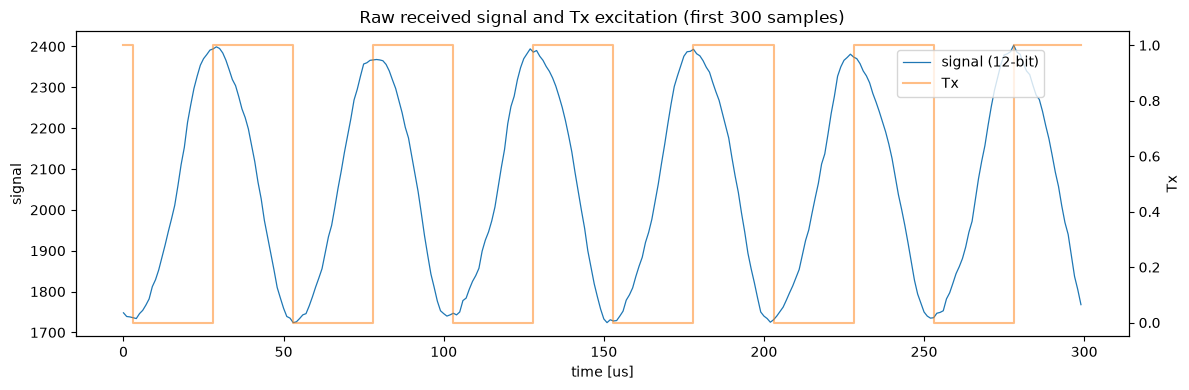

In [8]:
win = slice(0, 300)  # first 300 samples ~= 6 Tx periods

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t[win] * 1e6, signal[win], lw=0.9, label="signal (12-bit)")
ax2 = ax.twinx()
ax2.step(t[win] * 1e6, tx[win], where="post", color="tab:orange", alpha=0.5, label="Tx")
ax.set_xlabel("time [us]")
ax.set_ylabel("signal")
ax2.set_ylabel("Tx")
ax.set_title("Raw received signal and Tx excitation (first 300 samples)")
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()

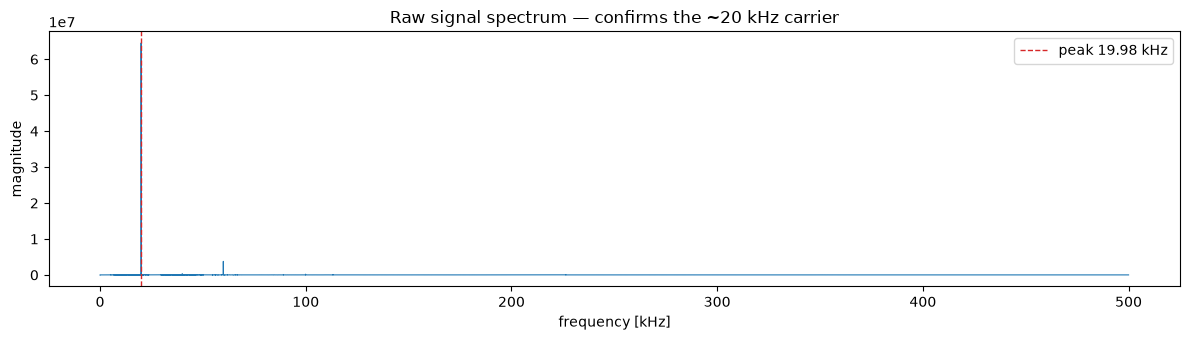

raw dominant frequency: 19.977 kHz


In [9]:
def dominant_freq(x, fs):
    """Dominant frequency of `x` (DC removed, Hann-windowed) in Hz."""
    x = x - x.mean()
    spec = np.abs(np.fft.rfft(x * np.hanning(x.size)))
    freqs = np.fft.rfftfreq(x.size, d=1 / fs)
    return freqs[np.argmax(spec)], freqs, spec


f0, freqs, spec = dominant_freq(signal, ADC_CLOCK_HZ)
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(freqs / 1e3, spec, lw=0.8)
ax.axvline(f0 / 1e3, color="tab:red", ls="--", lw=1, label=f"peak {f0/1e3:.2f} kHz")
ax.set_xlabel("frequency [kHz]")
ax.set_ylabel("magnitude")
ax.set_title("Raw signal spectrum — confirms the ~20 kHz carrier")
ax.legend()
plt.tight_layout()
plt.show()
print(f"raw dominant frequency: {f0/1e3:.3f} kHz")

## 3. Stage-1 demodulation — sliding-window peak-to-peak (1 MHz)

`max - min` over a one-Tx-period window slid at the full sample rate. Output stays at
1 MHz (no decimation). This is an AM envelope detector for the ~20 kHz carrier.

stage-1 sample rate     : 1000 kHz
stage-1 dominant freq   : 10.0 Hz  (a low-freq envelope, not 20 kHz)
stage-1 mean / std      : 1749.7 / 1099.9


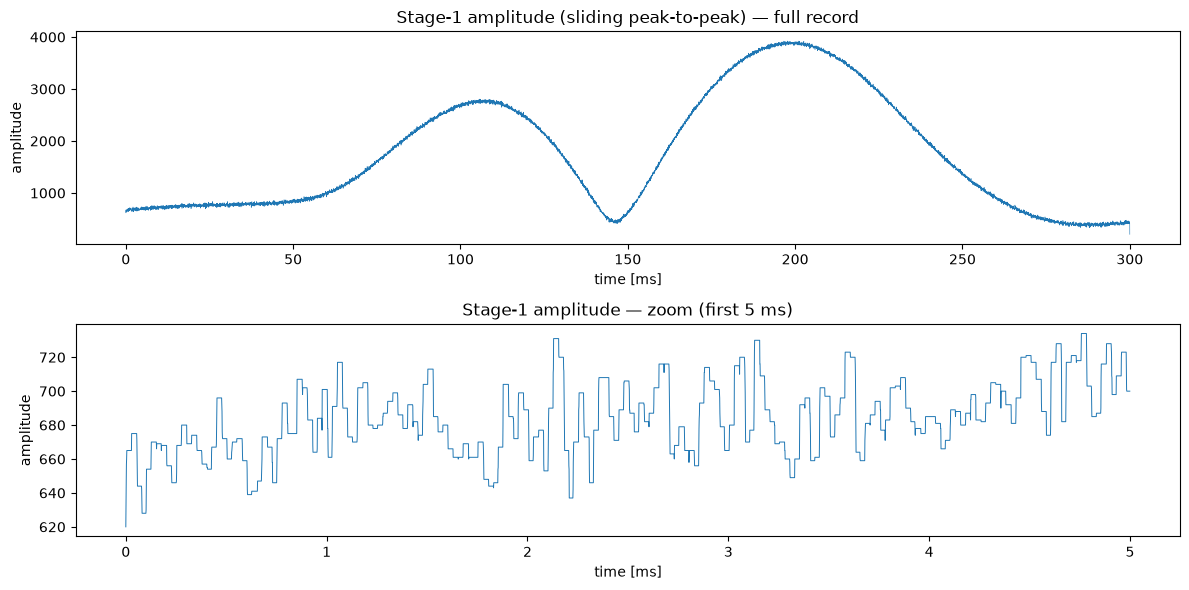

In [10]:
def sliding_peak_to_peak(sig, win):
    """Centred rolling max - min over `win` samples, at the input sample rate."""
    return (maximum_filter1d(sig, win) - minimum_filter1d(sig, win)).astype(float)


amp1 = sliding_peak_to_peak(signal, WIN)
fs1 = ADC_CLOCK_HZ  # stage-1 keeps the full rate

f1, _, _ = dominant_freq(amp1, fs1)
print(f"stage-1 sample rate     : {fs1/1e3:.0f} kHz")
print(f"stage-1 dominant freq   : {f1:.1f} Hz  (a low-freq envelope, not 20 kHz)")
print(f"stage-1 mean / std      : {amp1.mean():.1f} / {amp1.std():.1f}")

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(t * 1e3, amp1, lw=0.4)
axes[0].set_title("Stage-1 amplitude (sliding peak-to-peak) — full record")
axes[0].set_xlabel("time [ms]"); axes[0].set_ylabel("amplitude")
zoom = slice(0, 5000)
axes[1].plot(t[zoom] * 1e3, amp1[zoom], lw=0.7)
axes[1].set_title("Stage-1 amplitude — zoom (first 5 ms)")
axes[1].set_xlabel("time [ms]"); axes[1].set_ylabel("amplitude")
plt.tight_layout()
plt.show()

## 4. Stage-2 demodulation — envelope of the stage-1 signal

Per the email, demodulate the stage-1 signal again. Empirically stage-1 is already an
envelope, so this Hilbert pass mainly removes residual ripple and yields the smooth
probe-variation signal.

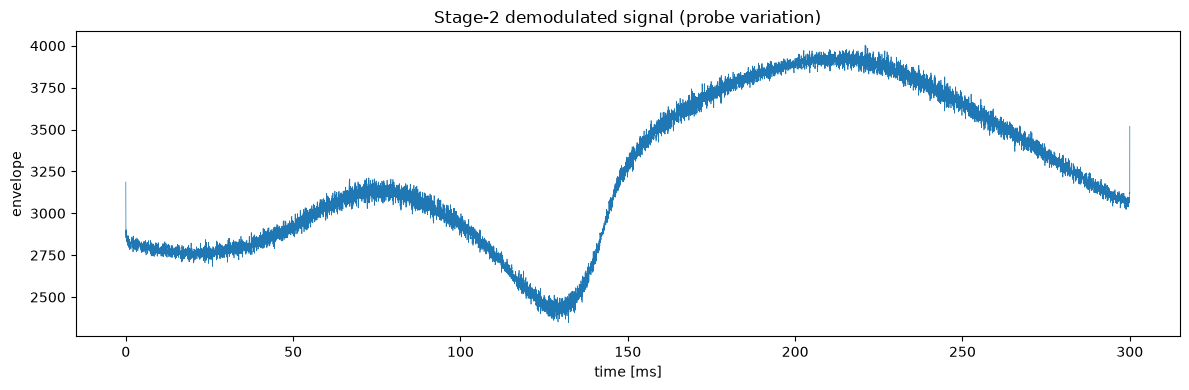

In [11]:
amp2 = np.abs(hilbert(amp1 - amp1.mean())) + amp1.mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t * 1e3, amp2, lw=0.5)
ax.set_xlabel("time [ms]"); ax.set_ylabel("envelope")
ax.set_title("Stage-2 demodulated signal (probe variation)")
plt.tight_layout()
plt.show()

## 5. Prepare for defect analysis — decimate

The defect is tens...hundreds of Hz, so decimate the probe-variation signal to a much
lower rate (anti-alias filtered) before the defect search. This makes both the
band-pass and the wavelet transform cheap and well-conditioned.

In [12]:
Q = 50                      # 1 MHz -> 20 kHz (Nyquist 10 kHz, covers hundreds of Hz)
fsd = ADC_CLOCK_HZ // Q
env = decimate(amp2, Q, ftype="fir", zero_phase=True)
td = np.arange(env.size) / fsd
GUARD = int(0.01 * fsd)     # ignore first/last 10 ms (filter edge transients)
print(f"decimated rate : {fsd/1e3:.1f} kHz, {env.size} samples, edge guard {GUARD} samples")

decimated rate : 20.0 kHz, 6000 samples, edge guard 200 samples


## 6. Defect detection — band-pass energy (baseline)

Band-pass to the defect range and take the analytic amplitude (local energy). Simple
and fast, but a stationary band-pass smears a single transient — compare against the
wavelet result below. **Tune `LO`/`HI` against the data.**

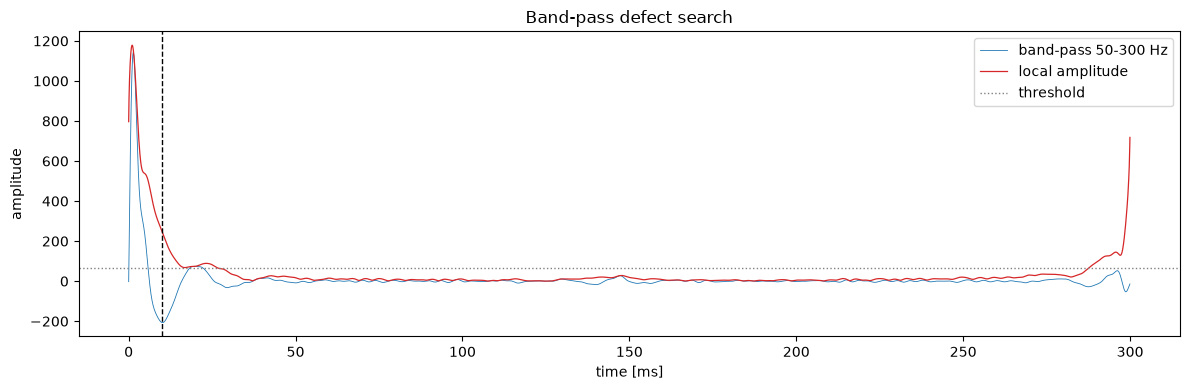

band-pass peak at t = 10.00 ms, energy/thr = 249/64.4
detected: True


In [13]:
LO, HI = 50.0, 300.0  # Hz — defect band (tune against the data)

sos = butter(4, [LO, HI], btype="band", fs=fsd, output="sos")
band = sosfiltfilt(sos, env - env.mean())
energy = np.abs(hilbert(band))

masked = energy.copy(); masked[:GUARD] = 0; masked[-GUARD:] = 0
peak_i = int(np.argmax(masked))
thr = np.median(energy) + 6 * (np.median(np.abs(energy - np.median(energy))) * 1.4826)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(td * 1e3, band, lw=0.6, label=f"band-pass {LO:.0f}-{HI:.0f} Hz")
ax.plot(td * 1e3, energy, lw=0.9, color="tab:red", label="local amplitude")
ax.axhline(thr, color="gray", ls=":", lw=1, label="threshold")
ax.axvline(td[peak_i] * 1e3, color="k", ls="--", lw=1)
ax.set_xlabel("time [ms]"); ax.set_ylabel("amplitude")
ax.set_title("Band-pass defect search")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()
print(f"band-pass peak at t = {td[peak_i]*1e3:.2f} ms, energy/thr = {energy[peak_i]:.3g}/{thr:.3g}")
print(f"detected: {bool(energy[peak_i] > thr)}")

## 7. Defect detection — continuous wavelet transform (CWT)

A complex Morlet CWT gives a time-frequency scalogram. A single low-frequency
sinusoidal pulse appears as a compact bright blob, localized in **both** time and
frequency. Detection uses the CWT **magnitude** (`|coeffs|`), which is phase-
insensitive — so the unreliable phase of the demodulated signal does not affect it.
This is why wavelets are preferred here over phase-dependent methods.

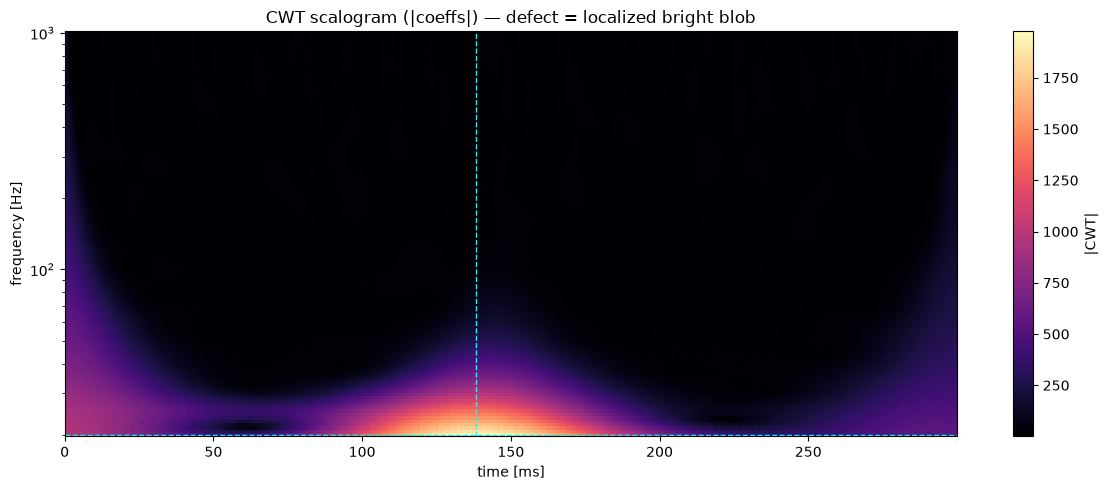

CWT peak: t = 138.40 ms, f = 20.0 Hz


In [14]:
WAVELET = "cmor1.5-1.0"  # complex Morlet (bandwidth-1.5, centre-1.0)
target_freqs = np.geomspace(20, 1000, 120)  # defect search band [Hz]
fc = pywt.central_frequency(WAVELET)
scales = fc * fsd / target_freqs

coef, freqs_w = pywt.cwt(env - env.mean(), scales, WAVELET, sampling_period=1 / fsd)
mag = np.abs(coef)

# Zero the time edges so transient ringing doesn't dominate the detection.
mag_m = mag.copy(); mag_m[:, :GUARD] = 0; mag_m[:, -GUARD:] = 0
s_idx, t_idx = np.unravel_index(np.argmax(mag_m), mag_m.shape)

fig, ax = plt.subplots(figsize=(12, 5))
pcm = ax.pcolormesh(td * 1e3, freqs_w, mag, shading="auto", cmap="magma")
ax.axvline(td[t_idx] * 1e3, color="cyan", ls="--", lw=1)
ax.axhline(freqs_w[s_idx], color="cyan", ls="--", lw=1)
ax.set_yscale("log")
ax.set_xlabel("time [ms]"); ax.set_ylabel("frequency [Hz]")
ax.set_title("CWT scalogram (|coeffs|) — defect = localized bright blob")
fig.colorbar(pcm, ax=ax, label="|CWT|")
plt.tight_layout()
plt.show()
print(f"CWT peak: t = {td[t_idx]*1e3:.2f} ms, f = {freqs_w[s_idx]:.1f} Hz")

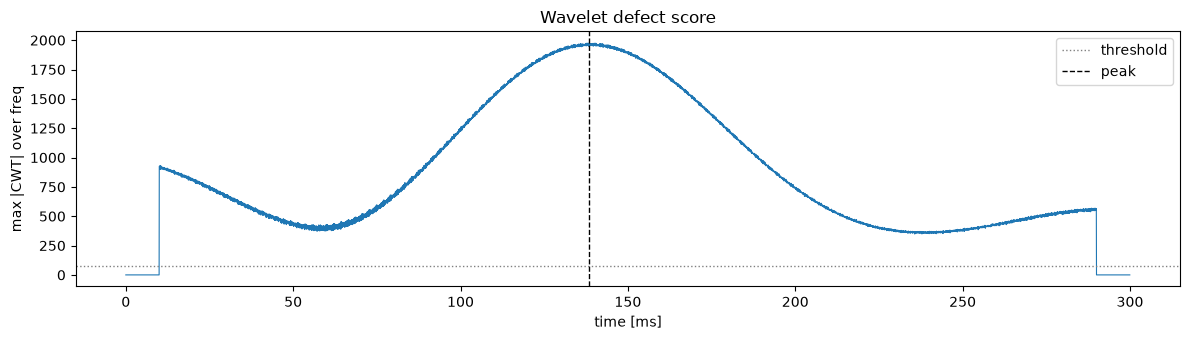

defect @ t = 138.40 ms, f = 20.0 Hz
score/thr = 1.98e+03/71.8  ->  detected: True


In [15]:
# Collapse the scalogram across frequency -> a time-localized defect score.
score = mag_m.max(axis=0)
thr_w = np.median(mag) + 6 * (np.median(np.abs(mag - np.median(mag))) * 1.4826)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(td * 1e3, score, lw=0.8)
ax.axhline(thr_w, color="gray", ls=":", lw=1, label="threshold")
ax.axvline(td[t_idx] * 1e3, color="k", ls="--", lw=1, label="peak")
ax.set_xlabel("time [ms]"); ax.set_ylabel("max |CWT| over freq")
ax.set_title("Wavelet defect score")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

detected = score[t_idx] > thr_w
print(f"defect @ t = {td[t_idx]*1e3:.2f} ms, f = {freqs_w[s_idx]:.1f} Hz")
print(f"score/thr = {score[t_idx]:.3g}/{thr_w:.3g}  ->  detected: {bool(detected)}")

## Notes / next steps

- **20 kHz reconciliation:** the raw signal is the ~20 kHz carrier; `max - min`
  demodulates it to a low-frequency envelope. The "sinusoid of nearly 20 kHz"
  refers to that raw carrier, not the demod output.
- **Tune** the wavelet `target_freqs` band and the detection thresholds once the
  defect's true frequency/location are confirmed visually on the scalogram.
- If multiple defects or repeated pulses are expected, replace the single-argmax
  detection with peak-finding over the wavelet score.
- Factor the demod + detection helpers into a reusable module once the pipeline
  stabilizes.